In [1]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sb
import csv
from scipy import stats
from scipy.spatial.distance import cosine
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [82]:
post_info = pd.read_csv("participant_content.csv")
list(post_info.columns)

['sessionId',
 'treatmentArm',
 'participantCode',
 'profilePicture',
 'firstName',
 'lastName',
 'bio',
 'postOrCommentId',
 'userContent',
 'staticContent',
 'dynamicContent',
 'postOrCommentText',
 'postOrCommentDate',
 'postLikes',
 'postDislikes',
 'participantLiked',
 'participantDisliked',
 'parentPost',
 'previousCommentOrPost',
 'dwellTimeInSeconds']

In [83]:
posts = post_info[(post_info.staticContent == 1) & pd.isnull(post_info.parentPost)]

In [84]:
likes = posts.groupby("postOrCommentText")['participantLiked'].sum().sort_values()
likes

postOrCommentText
There is no benefit to gun control                                                                                                                                                                                                                                                                                                                                              9.0
The 2nd Amendmentwas to prevent , from invasion and Tyrrany- They first thing the enemy want is your weapons!                                                                                                                                                                                                                                                                  12.0
Immigration is dangerous                                                                                                                                                                                                                      

Text(0.5, 1.0, 'Likes')

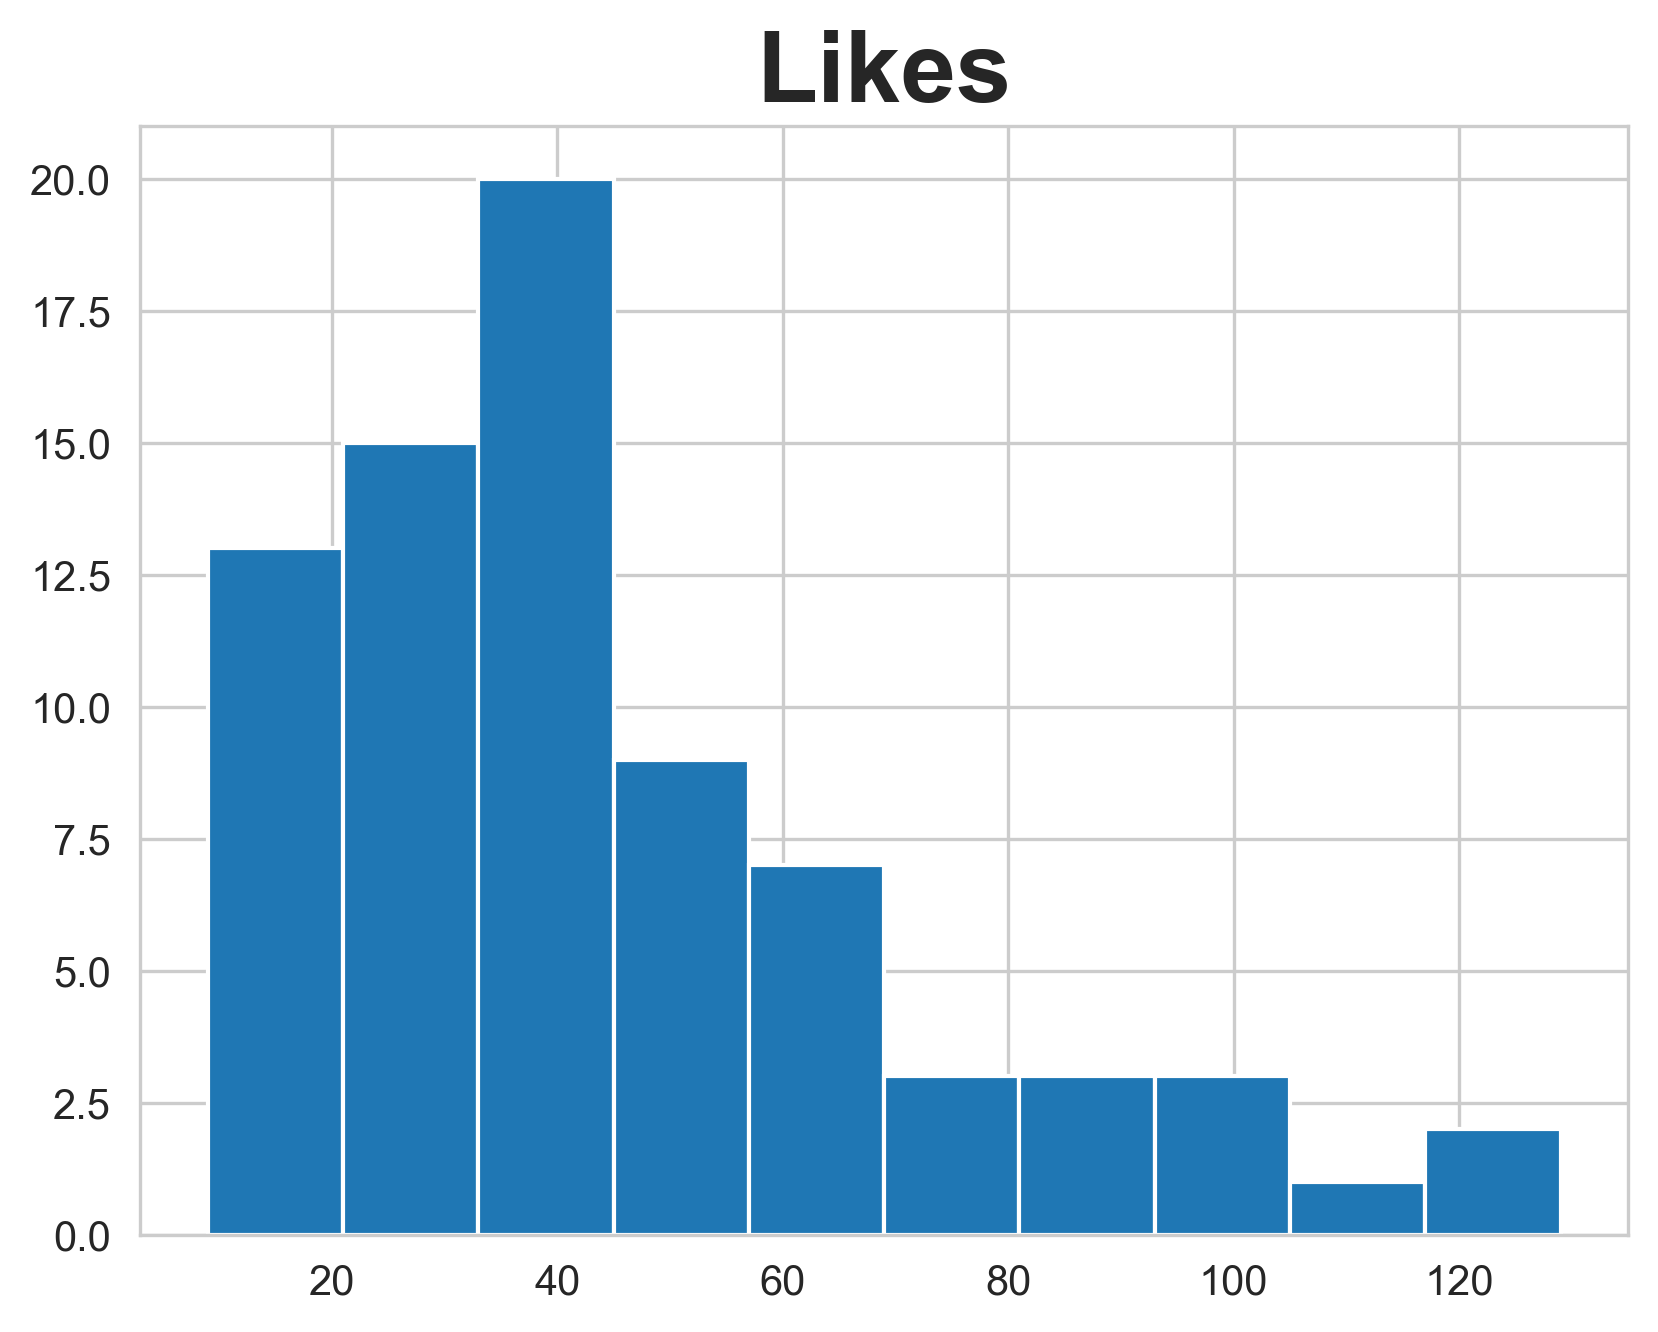

In [85]:
sb.set_style("whitegrid")
plt.figure(dpi=300)
plt.hist([i for i in likes.to_list() if i < 500])
plt.title("Likes", weight="bold", size=24)

In [86]:
dislikes = posts.groupby("postOrCommentText")['participantDisliked'].sum().sort_values()
dislikes

postOrCommentText
I try not to be naive that utopia exists or can exist. I know some people think differently, but I do believe in laws and rules and that people are basically good and follow them most of the time. I'd love to see data on this, but I feel like it's only the fringe that does not follow them and causes mayhem for the rest of us.                                        1.0
I understand it is a complex issue and I actually have no problem with asylum seekers. I personally believe that we should be letting in people who will come in to this country the legal way and assimilate into our country. This is just my perspective and open to hear the views of others.                                                                              2.0
Others might disagree, but I think we need reasonable and uniform NATIONAL gun legislation. I think one reason for the failure of gun control laws in the US is the pathwork of state-to-state differences. I might be wrong, but I think Congre

Text(0.5, 1.0, 'Dislikes')

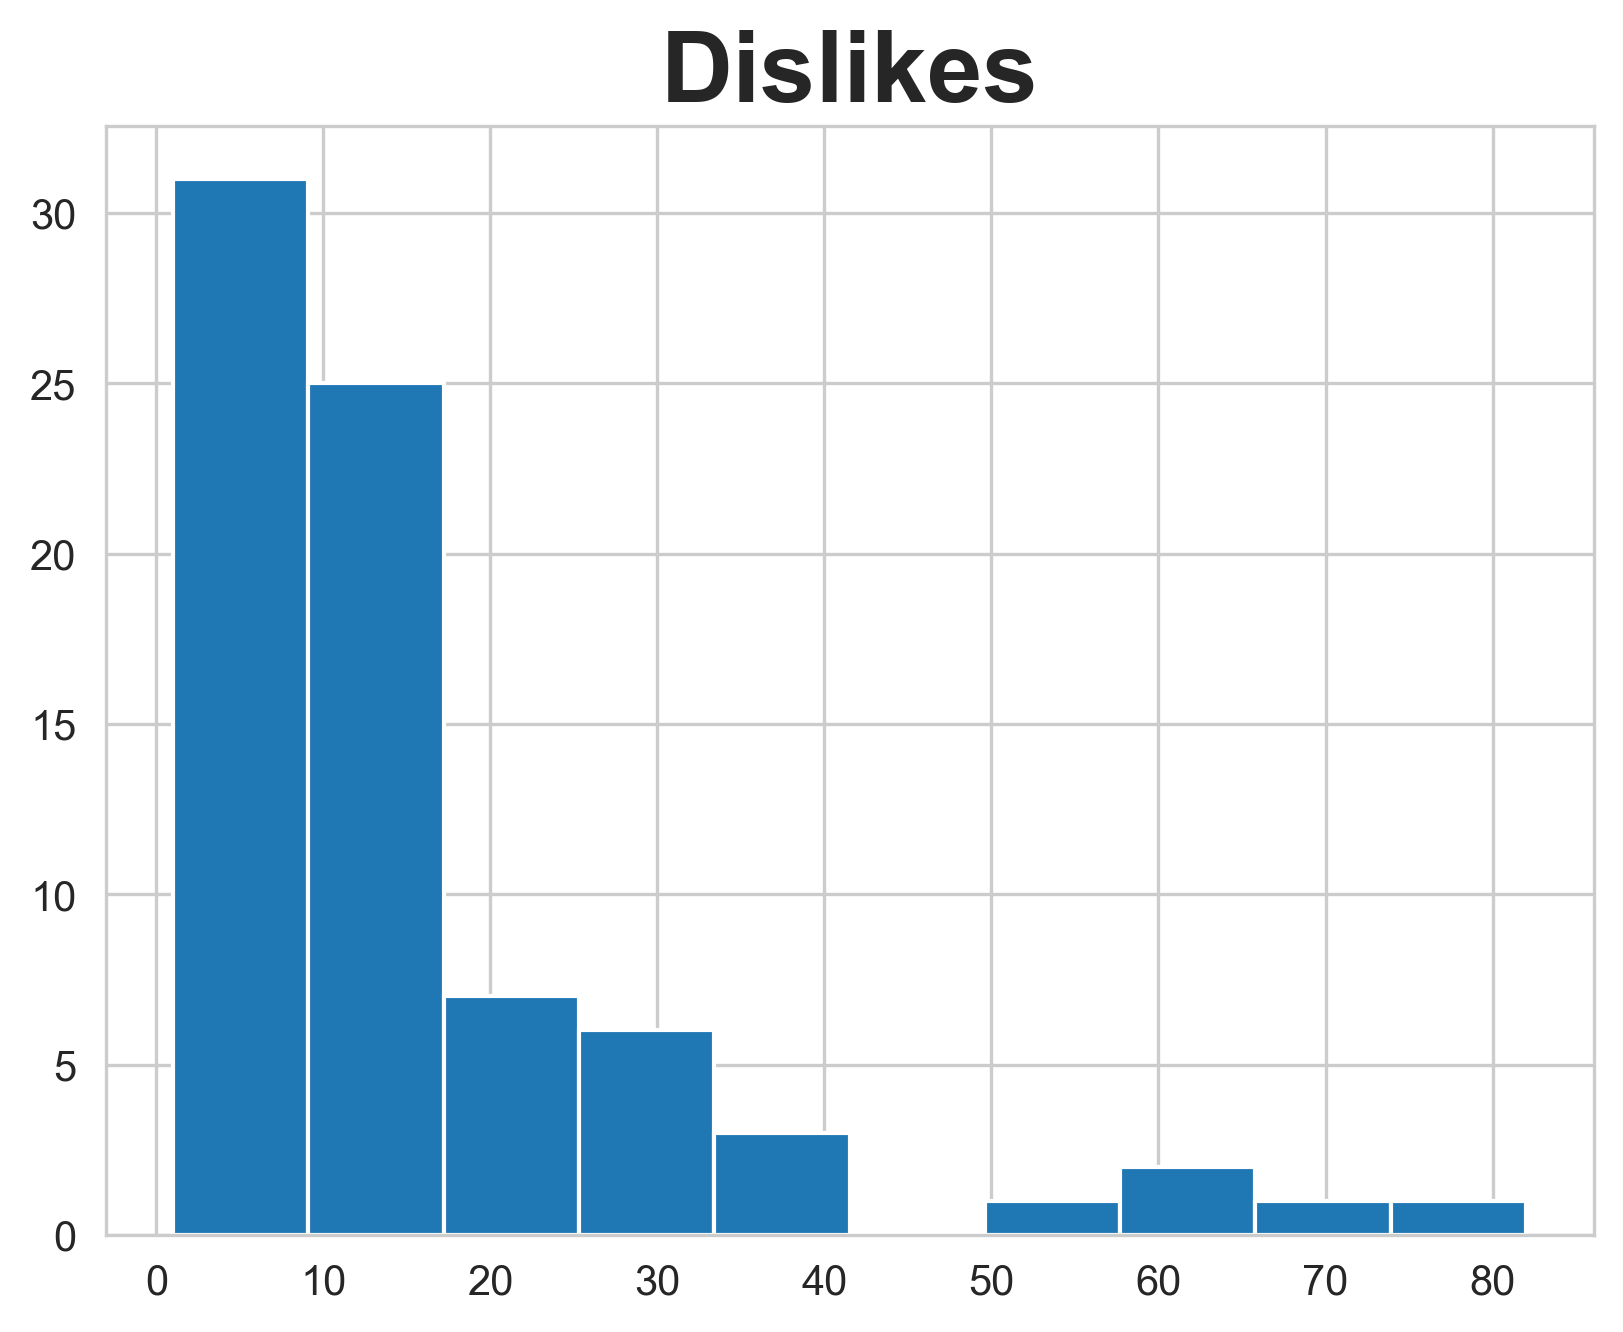

In [87]:
sb.set_style("whitegrid")
plt.figure(dpi=300)
plt.hist([i for i in dislikes.to_list() if i < 500])
plt.title("Dislikes", weight="bold", size=24)

In [88]:
np.median(likes)

41.0

In [89]:
np.median(dislikes)

13.0

In [97]:
df = pd.read_csv("PostInfo.csv")

Text(0.5, 1.0, 'Starting Likes')

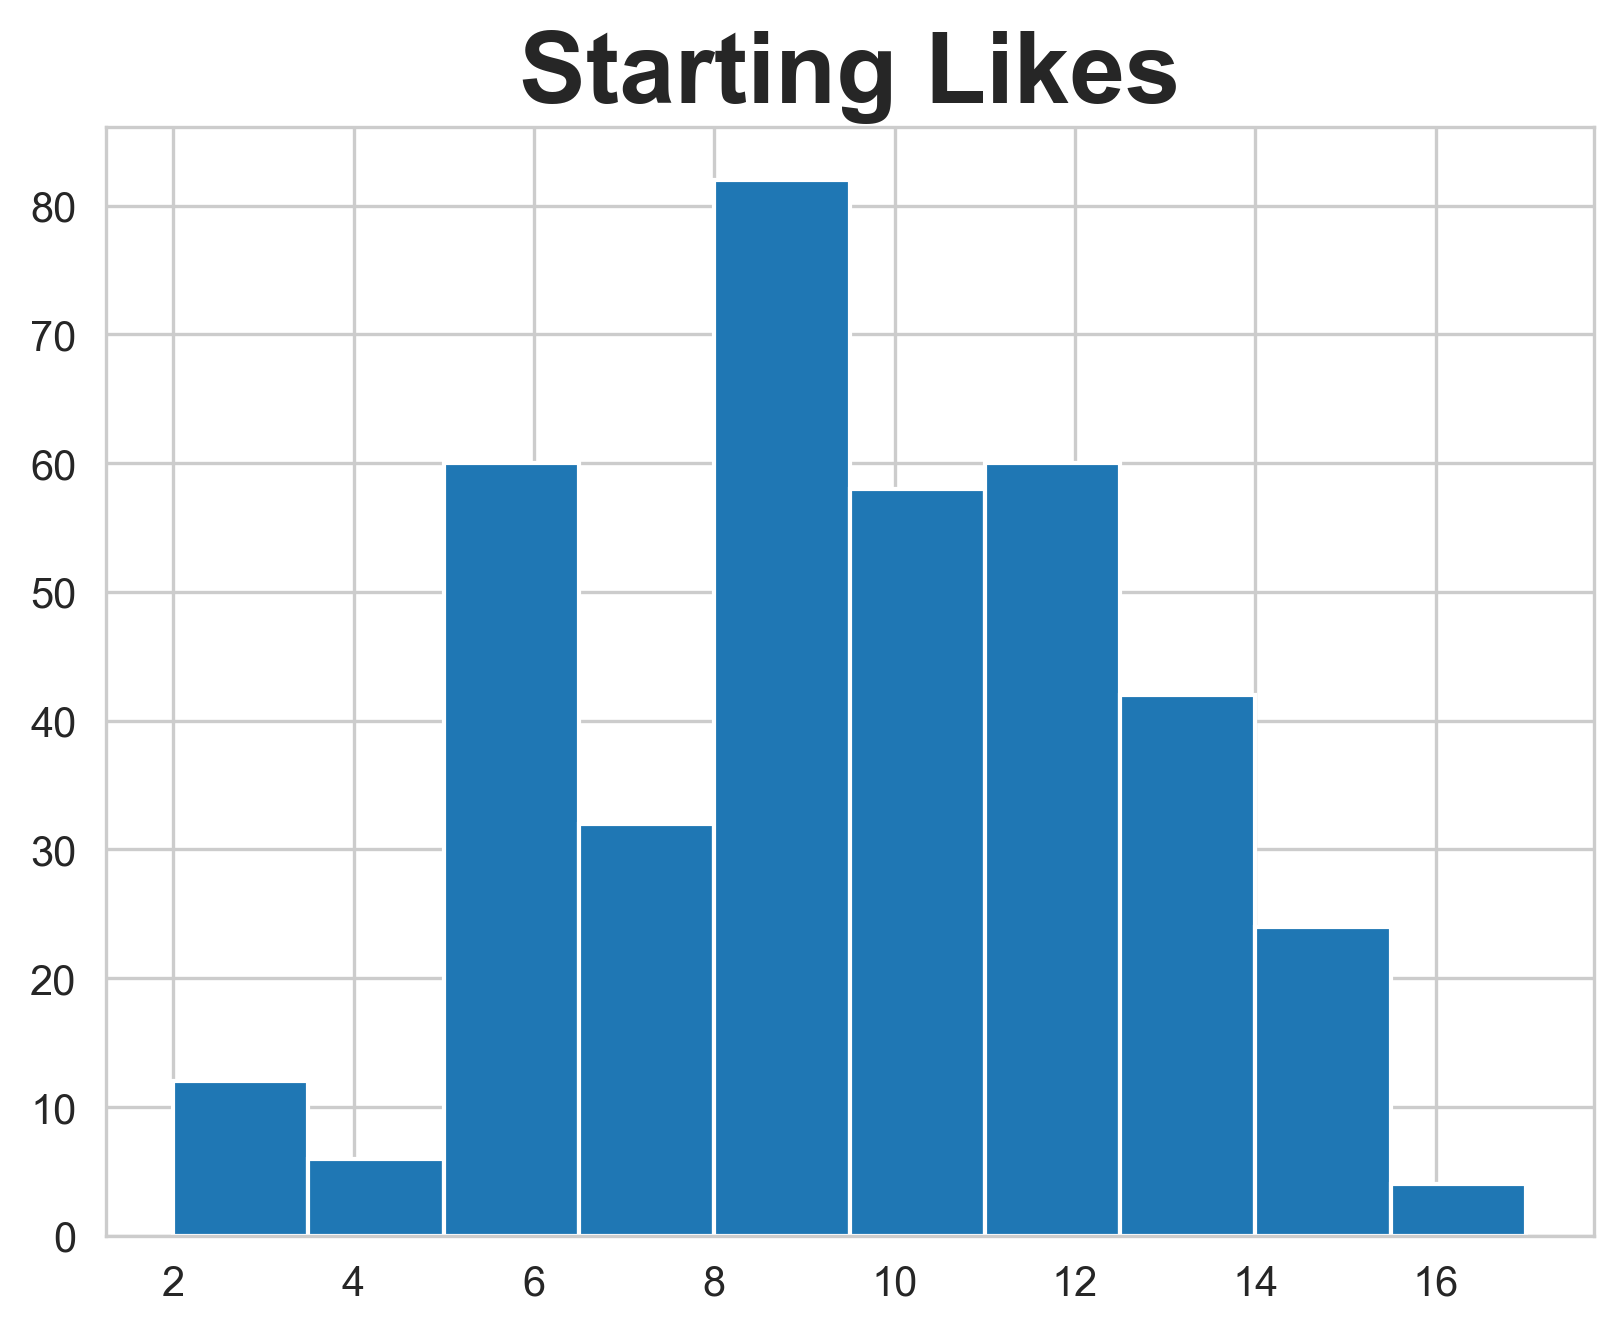

In [100]:
sb.set_style("whitegrid")
plt.figure(dpi=300)
plt.hist(df.Likes)
plt.title("Starting Likes", weight="bold", size=24)

Text(0.5, 1.0, 'Starting Dislikes')

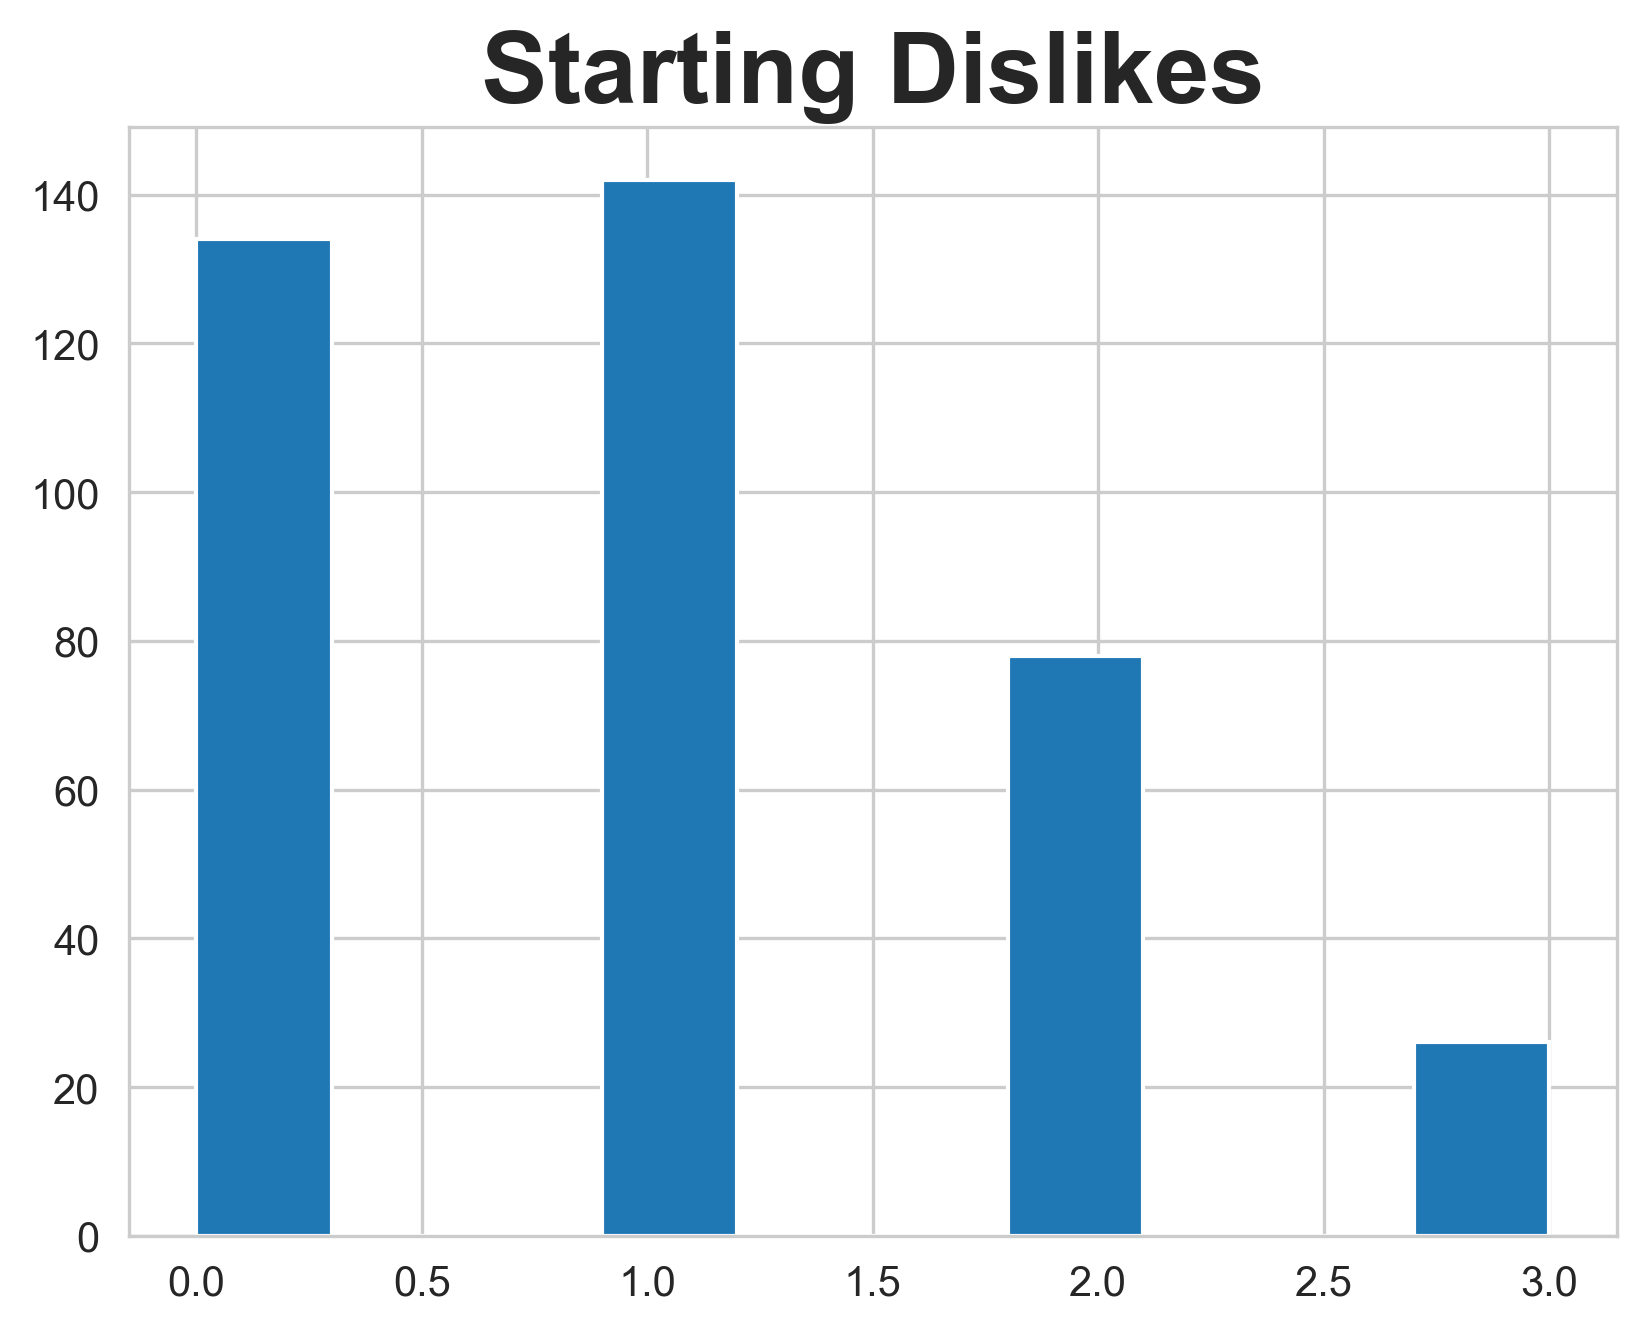

In [101]:
sb.set_style("whitegrid")
plt.figure(dpi=300)
plt.hist(df.Dislikes)
plt.title("Starting Dislikes", weight="bold", size=24)